**Trading Algorithm Script:** 

This script follows the DataCamp tutorial on visualising stock returns as time series data using the AlphaVantage API. It covers some of the most common financial analyses, like moving windows and volatility calcualtion using the Python pandas package. 

This script also develops a simple momentum strategy, backtests it, and optimises it to aid its performance in the future. 

There are some clear limitations to this script, as it only uses one stock across 100 days, which is far too short and narrow to draw any meaningful conclusions. Unfortunately, I am limited by the AlphaVantage API, which restricts me to using 100 days of data for each ticker. 

In [ ]:
# Installing the necessary packages:

%pip install pandas 
%pip install requests 
%pip install datetime 
%pip install pandas_datareader 
%pip install distutils 
%pip install beautifulsoup
%pip install bs4 
%pip install alphavantage
%pip install matplotlib 

In [2]:
import pandas_datareader as pdr 
import datetime
import requests as re 
from alpha_vantage.timeseries import TimeSeries
from bs4 import BeautifulSoup 
import pandas as pd 
import io 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
with open("API_key_3.txt") as file: 
    API_key = file.read()

In [ ]:
API_key = API_key.strip()
API_key

In [4]:
#Getting daily Apple stock data using requests package

url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=AAPL&apikey=' + str(API_key) + "&datatype=csv"
r = re.get(url).content 
aapl = pd.read_csv(io.StringIO(r.decode("utf-8")))
print(aapl)

     timestamp     open     high       low   close    volume
0   2026-03-16  252.105  253.885  249.8800  252.82  32074209
1   2026-03-13  255.480  256.330  249.5200  250.12  36929988
2   2026-03-12  258.660  258.950  254.1800  255.76  40794020
3   2026-03-11  261.090  262.130  259.5500  260.81  26218927
4   2026-03-10  257.645  262.480  256.9500  260.83  30590765
..         ...      ...      ...       ...     ...       ...
95  2025-10-27  264.880  269.120  264.6501  268.81  44888152
96  2025-10-24  261.190  264.130  259.1800  262.82  38253717
97  2025-10-23  259.940  260.620  258.0101  259.58  32754941
98  2025-10-22  262.650  262.850  255.4300  258.45  45015254
99  2025-10-21  261.880  265.290  261.8300  262.77  46695948

[100 rows x 6 columns]


In [ ]:
# Alternative way to get daily Apple stock data using alphavantage package: 

ts1 = TimeSeries(key = API_key)
ts1.get_daily("AAPL")

In [15]:
print(aapl.head(10))
print(aapl.tail(10))

    timestamp     open     high       low   close    volume
0  2026-03-16  252.105  253.885  249.8800  252.82  32074209
1  2026-03-13  255.480  256.330  249.5200  250.12  36929988
2  2026-03-12  258.660  258.950  254.1800  255.76  40794020
3  2026-03-11  261.090  262.130  259.5500  260.81  26218927
4  2026-03-10  257.645  262.480  256.9500  260.83  30590765
5  2026-03-09  255.690  261.150  253.6805  259.88  38218533
6  2026-03-06  258.630  258.770  254.3700  257.46  41120042
7  2026-03-05  260.790  261.555  257.2500  260.29  49658626
8  2026-03-04  264.650  266.150  261.4200  262.52  39803119
9  2026-03-03  263.480  265.560  260.1300  263.75  38568921
     timestamp     open    high       low   close    volume
90  2025-11-03  270.420  270.85  266.2500  269.05  50194583
91  2025-10-31  276.990  277.32  269.1600  270.37  86167123
92  2025-10-30  271.990  274.14  268.4800  271.40  69886534
93  2025-10-29  269.275  271.41  267.1100  269.70  51086742
94  2025-10-28  268.985  269.89  268.150

In [5]:
aapl.to_csv('AAPLstockdata.csv')

In [34]:
# Checking columns of the data 
print(aapl.columns)

# Checking rows of the data 
print(aapl.index) 

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
RangeIndex(start=0, stop=100, step=1)


<Axes: >

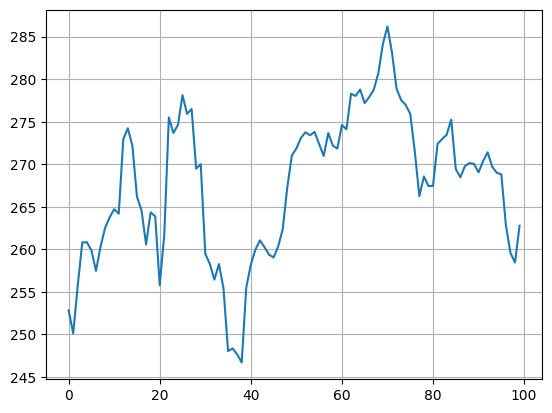

In [17]:
# Plotting time series of closing daily values of AAPL stock 
aapl['close'].plot(grid = True)

<Axes: >

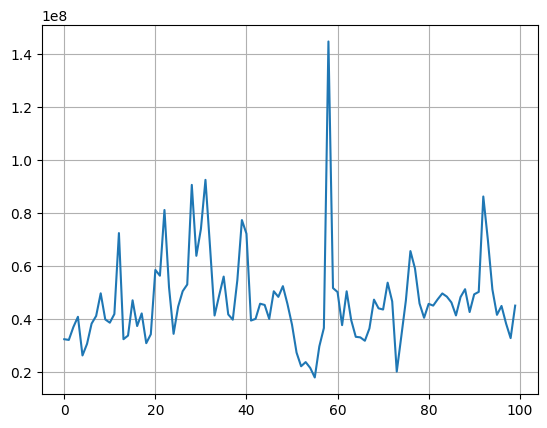

In [36]:
# Plotting time series of volume of AAPL stock traded 
aapl['volume'].plot(grid = True)

0          NaN
1    -0.010737
2     0.022299
3     0.019553
4     0.000077
        ...   
95   -0.000707
96   -0.022535
97   -0.012404
98   -0.004363
99    0.016577
Name: close, Length: 100, dtype: float64


<Axes: >

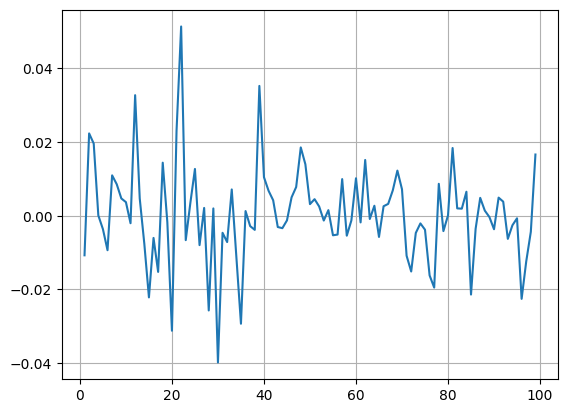

In [6]:
# Calculating and plotting daily log returns
daily_log_returns_shift = np.log(aapl['close']/aapl['close'].shift(1))
print(daily_log_returns_shift)
daily_log_returns_shift.plot(grid = True)

<Axes: >

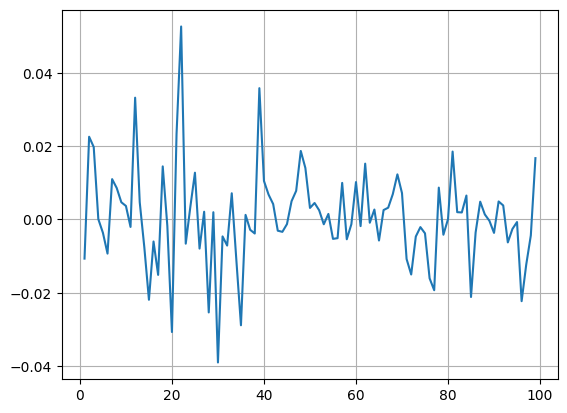

In [7]:
# Calculating actual daily returns 
aapl['Returns'] = aapl['close'].pct_change()
daily_returns = aapl[['Returns']]
aapl['Returns'].plot(grid = True)

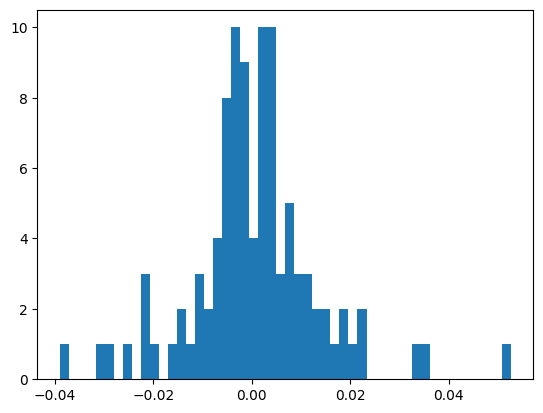

         Returns
count  99.000000
mean    0.000477
std     0.013278
min    -0.038999
25%    -0.005200
50%     0.000075
75%     0.006643
max     0.052611


In [ ]:
# Plotting distribution of returns 
plt.hist(daily_returns, bins = 50)
plt.show()

# Summary statistics of daily returns 
print(daily_returns.describe())

     Returns
0        NaN
1   0.989320
2   1.011629
3   1.031604
4   1.031683
..       ...
95  1.063247
96  1.039554
97  1.026738
98  1.022269
99  1.039356

[100 rows x 1 columns]


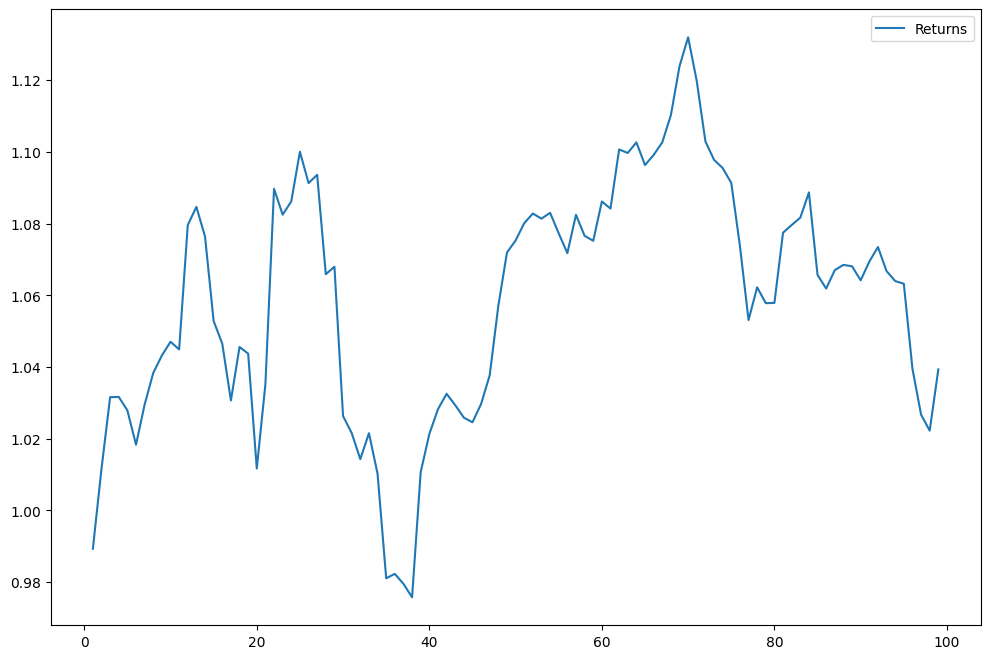

In [8]:
# Calculating cumulative returns 

cum_return = (1 + daily_returns).cumprod()
print(cum_return)

cum_return.plot(figsize = (12,8))
plt.show()

**Moving windows:**

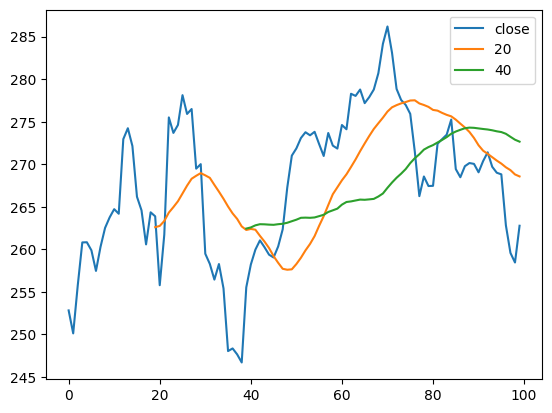

In [9]:
close_px = aapl['close']

# Short moving window rolling mean: 
aapl['20'] = close_px.rolling(window = 20).mean()

# Long moving window rolling mean: 
aapl['40'] = close_px.rolling(window = 40).mean()

# Plotting the closing price with the short and long windows of rolling means: 

aapl[['close', '20', '40']].plot()
plt.show()

**Volatility:**

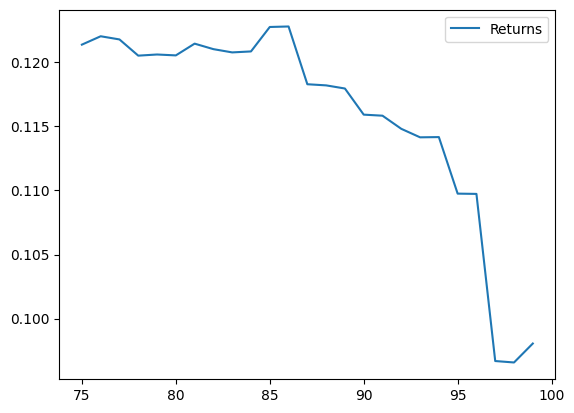

In [10]:
# Calculating volatility: 

min_periods = 75
vol = daily_returns.rolling(min_periods).std() * np.sqrt(min_periods)

# Plotting volatility: 
vol.plot()
plt.show()

**Trading Strategy:** 

In [11]:
short_window = 20
long_window = 40

# Creating a DF called "signals" which includes a column called "signal"
signals = pd.DataFrame(index = aapl.index)
signals['signal'] = 0.0

# Creating a short simple moving average over the short window: 
signals['short_MA'] = aapl['close'].rolling(window = short_window, min_periods = 1, center = False).mean()

# Creating a long simple moving average over the short window: 
signals['long_MA'] = aapl['close'].rolling(window = long_window, min_periods = 1, center = False).mean()

# Creating signals: 
signals['signal'][short_window:] = np.where(signals['short_MA'][short_window:] > signals['long_MA'][short_window:], 1.0, 0.0)

# Trading orders: 
signals['positions'] = signals['signal'].diff()

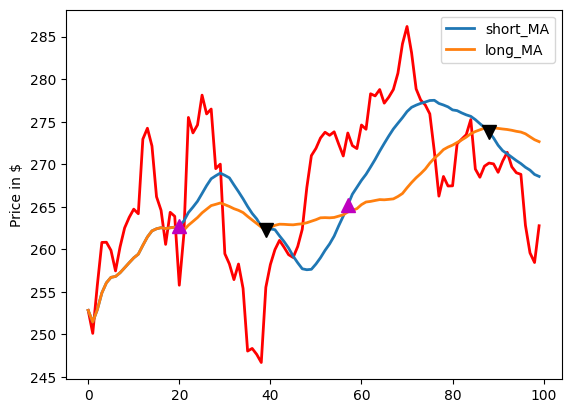

In [ ]:
# Plotting the short and long moving averages, as well as the buying and selling signals: 

fig = plt.figure()

ax1 = fig.add_subplot(111, ylabel = 'Price in $')

aapl['close'].plot(ax = ax1, color = 'red', lw = 2.)

signals[['short_MA', 'long_MA']].plot(ax = ax1, lw = 2.)

# Plotting buy signals: 
ax1.plot(signals.loc[signals.positions == 1.0].index, signals.short_MA[signals.positions == 1.0], '^', markersize = 10, color = 'm')

# Plotting sell signals: 
ax1.plot(signals.loc[signals.positions == -1.0].index, signals.short_MA[signals.positions == -1.0], 'v', markersize = 10, color = 'k')

plt.show()

**Backtesting the strategy:**

In [13]:
# Setting initial capital: 
initial_capital = float(100000.0)

# Creating a DataFrame: 
positions = pd.DataFrame(index = signals.index).fillna(0.0)

# Starting off with buying 100 Apple shares: 
positions['AAPL'] = 100*signals['signal']   
  
# Initialize the portfolio with value owned   
portfolio = positions.multiply(aapl['close'], axis=0)

# Store the difference in shares owned 
pos_diff = positions.diff()

# Add `holdings` to portfolio
portfolio['holdings'] = (positions.multiply(aapl['close'], axis=0)).sum(axis=1)

# Add `cash` to portfolio
portfolio['cash'] = initial_capital - (pos_diff.multiply(aapl['close'], axis=0)).sum(axis=1).cumsum()   

# Add `total` to portfolio
portfolio['total'] = portfolio['cash'] + portfolio['holdings']

# Add `returns` to portfolio
portfolio['returns'] = portfolio['total'].pct_change()

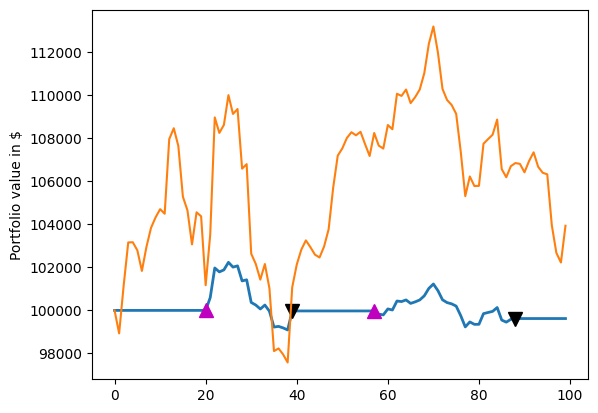

In [23]:
fig = plt.figure()

ax1 = fig.add_subplot(111, ylabel='Portfolio value in $')

# Plot the equity curve in dollars
portfolio['total'].plot(ax=ax1, lw=2.)

# Plot the "buy" trades against the equity curve
ax1.plot(portfolio.loc[signals.positions == 1.0].index, 
         portfolio.total[signals.positions == 1.0],
         '^', markersize=10, color='m')

# Plot the "sell" trades against the equity curve
ax1.plot(portfolio.loc[signals.positions == -1.0].index, 
         portfolio.total[signals.positions == -1.0],
         'v', markersize=10, color='k')

buy_and_hold = initial_capital * (aapl['close'] / aapl['close'].iloc[0])
ax1.plot(buy_and_hold)

# Show the plot
plt.show()

It looks like our strategy has performed poorly! We see that our portfolio not only fell in value, but failed to beat the basic strategy of buying the stock and holding it. 

**Evaluating the Moving Average Crossover Strategy:**

Sharpe Ratio: 

In [15]:
returns = portfolio['returns']

sharpe_ratio = np.sqrt(252) * (returns.mean()/ returns.std())
print(sharpe_ratio)

-0.19764816178292846


Maximum Drawdown: 

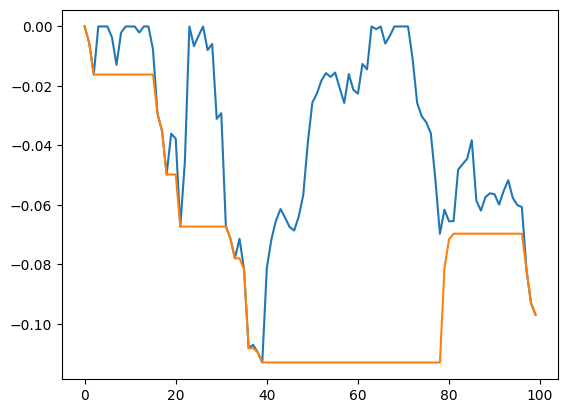

In [61]:
window = 40 

rolling_max = aapl['close'].rolling(window, min_periods = 1).max()
daily_drawdown = aapl['close']/rolling_max - 1

max_daily_drawdown = daily_drawdown.rolling(window, min_periods = 1).min()

daily_drawdown.plot()
max_daily_drawdown.plot()

plt.show()

Compound Annual Growth Rate (CAGR): 

In [20]:
# Number of days in series: 
days = len(aapl)
    # There are 100 rows in the scraped dataset, with one observation per day, indicating that we have 100 days 

# Calculate the CAGR 
cagr = ((((aapl['close'].iloc[-1]) / aapl['close'].iloc[1])) ** (365.0/days)) - 1

# Print CAGR
print(cagr)

0.19731898224641453
